In [1]:
from pathlib import Path

from typing import TypedDict
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
from rich.console import Console
from rich.pretty import Pretty
from rich.theme import Theme
from rich.panel import Panel
from rich.markdown import Markdown

theme = Theme(
    {
        "json.key": "#c1a2ff",
        "json.string": "#FCCEA1",
        "json.number": "#A1C4FD",
        "json.boolean": "#A6F5D8",
        "json.null": "#ffb3ba",
    }
)

console = Console(
    theme=theme,
    force_terminal=True,
    force_jupyter=False,
    color_system="truecolor",
)

load_dotenv()

True

In [2]:
# state
class QaState(TypedDict):
    query: str
    response: str

In [3]:
# LLm call
def llm_call(state: QaState) -> QaState:
    model = ChatGoogleGenerativeAI(
        model="gemini-3.5-flash",
        temperature=0.7,
        max_output_tokens=5000,
    )

    parser = StrOutputParser()
    chain = model | parser

    state["response"] = chain.invoke(f"You are a helpful assisstant, Answer following question\n{state['query']}")

    return state


In [4]:
# init graph
graph = StateGraph(QaState)


In [5]:
# add nodes
graph.add_node("llm_call", llm_call)

In [6]:
# add edges
graph.add_edge(START, "llm_call")
graph.add_edge("llm_call", END)

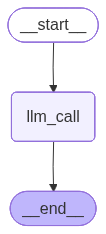

In [7]:
# compilation
workflow = graph.compile()
workflow

In [8]:
final_state = workflow.invoke({"query": "What is ROUGE evaluation metric? Answer in about 200 words"})
console.print_json(data=final_state)

{
  "query": "What is ROUGE evaluation metric? Answer in about 200 words",
  "response": "**ROUGE**, which stands for **Recall-Oriented Understudy for Gisting Evaluation**, is a widely used set of metrics in Natural Language Processing (NLP) designed to evaluate automatic text summarization and machine translation models. It works by comparing an automatically generated text (system summary) against one or more human-written reference texts.\n\nROUGE measures the overlap of words and phrases between the generated and reference texts. The most common variants include:\n\n*   **ROUGE-N:** Measures the overlap of $n$-grams. For example, **ROUGE-1** looks at individual word matches (unigrams), while **ROUGE-2** looks at two-word phrase matches (bigrams).\n*   **ROUGE-L:** Measures the Longest Common Subsequence (LCS). It identifies the longest shared sequence of words in the same order, which helps evaluate sentence-level structure and flow without requiring consecutive matches.\n*   **ROU

In [13]:
from rich.panel import Panel

console.print(
    Panel(
        Markdown(final_state["response"]),
        title="Response",
        border_style="#6CFCCE",
        expand=True,
    )
)


╭────────────────────────────────── Response ──────────────────────────────────╮
│ ROUGE, which stands for Recall-Oriented Understudy for Gisting Evaluation,   │
│ is a widely used set of metrics in Natural Language Processing (NLP)         │
│ designed to evaluate automatic text summarization and machine translation    │
│ models. It works by comparing an automatically generated text (system        │
│ summary) against one or more human-written reference texts.                  │
│                                                                              │
│ ROUGE measures the overlap of words and phrases between the generated and    │
│ reference texts. The most common variants include:                           │
│                                                                              │
│  • ROUGE-N: Measures the overlap of $n$-grams. For example, ROUGE-1 looks at │
│    individual word matches (unigrams), while ROUGE-2 looks at two-word       │
│    phrase matches (bigrams